This is the first file to run

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
DATA_PATH = Path("../data/raw/TotalDataSet.xlsx")  # adjust if your structure differs
df = pd.read_excel(DATA_PATH)

print("Shape:", df.shape)
print("Data types:\n", df.dtypes)

Shape: (271, 17)
Data types:
 Year              int64
Index No.           str
FinalGPA        float64
S1              float64
S2              float64
S3              float64
S4              float64
S5              float64
S6              float64
S7              float64
S8              float64
Department          str
Zscore          float64
Gender              str
EnglishMarks    float64
District            str
MediumAL            str
dtype: object


In [40]:
df.head()

,Year,Index No.,FinalGPA,S1,S2,S3,S4,S5,S6,S7,S8,Department,Zscore,Gender,EnglishMarks,District,Province,MediumAL
0,2017,176096J,3.88,3.76,3.98,3.86,3.80,3.89,3.89,3.79,3.99,BA,1.8487,F,66.0,Badulla,Uva,S
1,2017,176095F,3.67,3.58,3.28,3.64,3.75,3.34,4.02,3.88,3.85,BA,1.5718,M,82.0,Anuradhapura,North Central,E
2,2017,176094C,2.74,2.90,3.41,2.74,2.26,1.59,3.02,2.99,2.71,FSM,1.6005,M,NaN,Colombo,Western,S
3,2017,176093X,3.36,3.35,3.00,3.11,3.05,2.59,3.91,3.84,3.90,BPM,1.7060,F,92.0,Ratnapura,Sabaragamuwa,S
4,2017,176092T,3.83,3.49,3.73,3.65,4.07,3.85,4.02,4.05,3.89,BA,1.5602,F,76.0,Kalutara,Western,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 271 entries, 0 to 270
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          271 non-null    int64  
 1   Index No.     271 non-null    str    
 2   FinalGPA      271 non-null    float64
 3   S1            271 non-null    float64
 4   S2            271 non-null    float64
 5   S3            271 non-null    float64
 6   S4            271 non-null    float64
 7   S5            271 non-null    float64
 8   S6            271 non-null    float64
 9   S7            271 non-null    float64
 10  S8            271 non-null    float64
 11  Department    271 non-null    str    
 12  Zscore        271 non-null    float64
 13  Gender        271 non-null    str    
 14  EnglishMarks  264 non-null    float64
 15  District      271 non-null    str    
 16  MediumAL      271 non-null    str    
dtypes: float64(11), int64(1), str(5)
memory usage: 41.2 KB


In [4]:
df.isna().sum().sort_values(ascending=False)


EnglishMarks    7
Year            0
Index No.       0
S1              0
FinalGPA        0
S3              0
S4              0
S5              0
S2              0
S6              0
S7              0
Department      0
S8              0
Zscore          0
Gender          0
District        0
MediumAL        0
dtype: int64

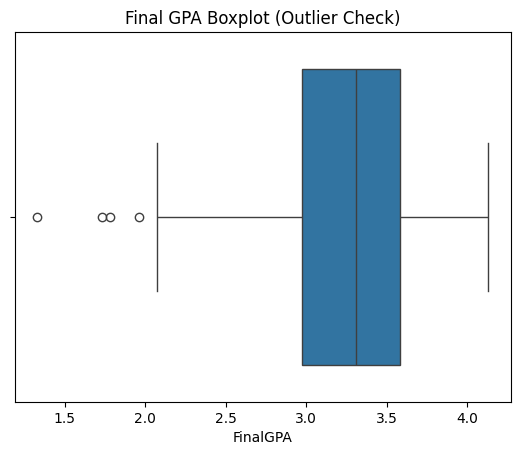

,Year,FinalGPA,S1,S2,S3,S4,S5,S6,S7,S8,Zscore,EnglishMarks
count,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,264.000000
mean,2018.029520,3.259815,3.201882,3.278598,3.130111,3.276458,3.144280,3.349262,3.320480,3.337196,1.575396,52.458333
std,0.811409,0.465974,0.477834,0.542115,0.579209,0.514028,0.614692,0.608288,0.665281,0.617312,0.160651,21.421494
min,2017.000000,1.330000,1.790000,1.290000,1.150000,0.490000,0.000000,0.000000,0.000000,0.000000,1.029400,3.000000
25%,2017.000000,2.970000,2.830000,2.970000,2.695000,2.985000,2.815000,3.095000,3.100000,3.120000,1.517750,38.750000
50%,2018.000000,3.310000,3.240000,3.340000,3.180000,3.360000,3.230000,3.470000,3.510000,3.450000,1.574500,53.000000
75%,2019.000000,3.580000,3.580000,3.690000,3.610000,3.625000,3.590000,3.780000,3.730000,3.710000,1.627100,68.000000
max,2019.000000,4.130000,4.150000,4.200000,4.180000,4.200000,4.130000,4.110000,4.130000,4.130000,2.632000,92.000000


In [5]:
# print(df[["FinalGPA", "Zscore", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8","EnglishMarks"]].describe())

plt.figure()
sns.boxplot(x=df["FinalGPA"])
plt.title("Final GPA Boxplot (Outlier Check)")
plt.show()

df.describe()

In [6]:
def ClassCounts(FinalGPA):
    if FinalGPA <= 1.99:
        return "Fail"
    elif FinalGPA <= 2.99:
        return "Pass"
    elif FinalGPA <= 3.29:
        return "Second Lower"
    elif FinalGPA <= 3.69:
        return "Second Upper"
    else:
        return "High"

df["PerfGroup"] = df["FinalGPA"].apply(ClassCounts)
print(df["PerfGroup"].value_counts())

pd.crosstab(df["Year"], df["PerfGroup"])


PerfGroup
Second Upper    92
Pass            66
Second Lower    62
High            47
Fail             4
Name: count, dtype: int64


PerfGroup,Fail,High,Pass,Second Lower,Second Upper
Year,,,,,
2017,1,12,25,18,29
2018,1,16,19,25,32
2019,2,19,22,19,31


Based on above counts:
Pass and fail are underperforming
Second Lower is Average
Second upper and first class is Performing

In [9]:
def PerformanceGroupCounts(FinalGPA):
    if FinalGPA <= 2.00:
        return "Fail"
    elif FinalGPA <= 2.99:
        return "Pass"
    elif FinalGPA <= 3.29:
        return "Second Lower"
    elif FinalGPA <= 3.69:
        return "Second Upper"
    else:
        return "First class"

df["PerfGroup"] = df["FinalGPA"].apply(PerformanceGroupCounts)
print(df["PerfGroup"].value_counts())

PerfGroup
Second Upper    92
Pass            66
Second Lower    62
First class     47
Fail             4
Name: count, dtype: int64


In [10]:
def PerformanceGroupCounts(FinalGPA):
    if FinalGPA <= 2.99:
        return "Underperforming"
    elif FinalGPA <= 3.29:
        return "Average"
    else:
        return "Performing"

df["PerfGroup"] = df["FinalGPA"].apply(PerformanceGroupCounts)
print(df["PerfGroup"].value_counts())

PerfGroup
Performing         139
Underperforming     70
Average             62
Name: count, dtype: int64


In [11]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", cat_cols)

for c in cat_cols[1:]:
    print("\n")
    print(df[c].value_counts(dropna=False).head(20))

Categorical columns: ['Index No.', 'Department', 'Gender', 'District', 'MediumAL', 'PerfGroup']


Department
BA     116
BPM    112
FSM     43
Name: count, dtype: int64


Gender
F    166
M    105
Name: count, dtype: int64


District
Colombo         59
Gampaha         34
Kalutara        24
Matara          13
Kurunegala      13
Kandy           13
Anuradhapura    12
Galle           12
Ratnapura       11
Badulla          8
Batticaloa       7
Badulla          6
Puttalam         6
Kegalle          6
Nuwaraeliya      6
Ampara           6
Matale           4
Monaragala       4
Hambantota       4
Jaffna           4
Name: count, dtype: int64


MediumAL
S    216
T     33
E     22
Name: count, dtype: int64


PerfGroup
Performing         139
Underperforming     70
Average             62
Name: count, dtype: int64


C:\Users\saw\AppData\Local\Temp\ipykernel_37616\3693009448.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [12]:
count = (df[[f"S{i}" for i in range(1,9)]] == 0).sum()
print('Count of zero values in each semester column:')
print(count)

Count of zero values in each semester column:
S1    0
S2    0
S3    0
S4    0
S5    2
S6    2
S7    3
S8    4
dtype: int64


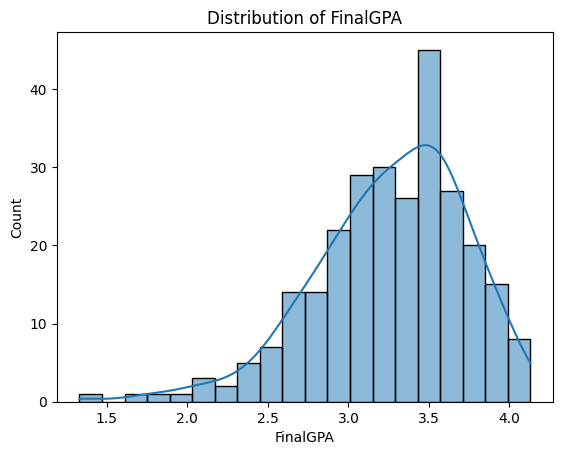

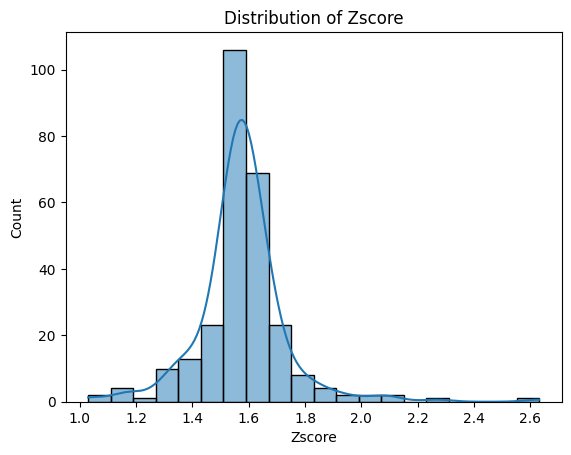

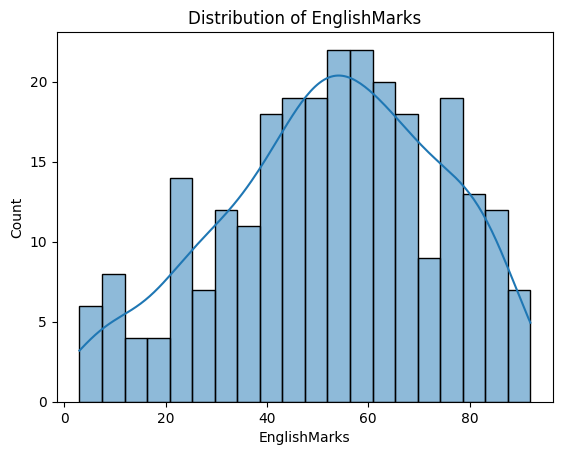

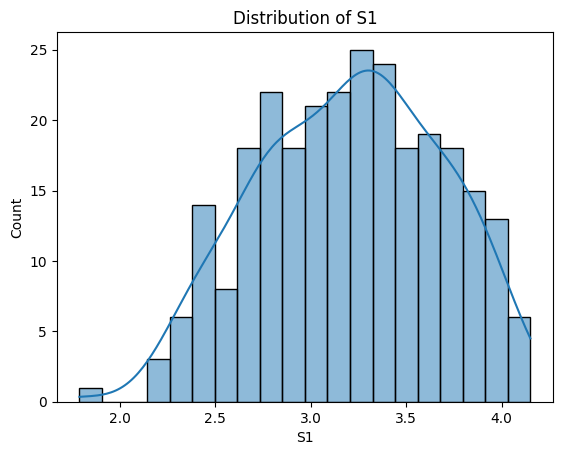

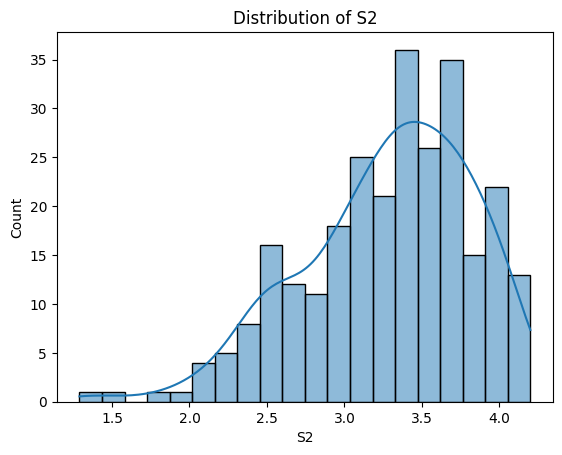

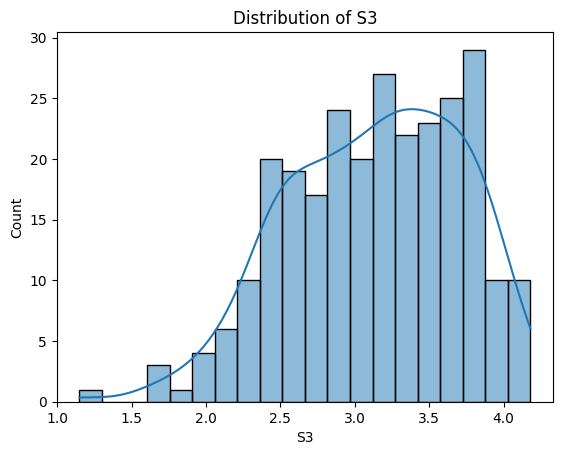

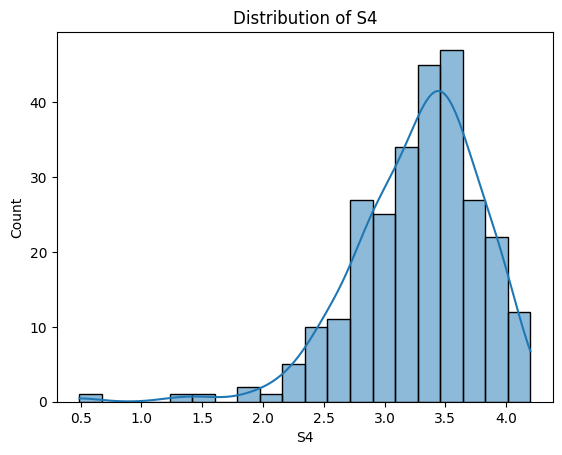

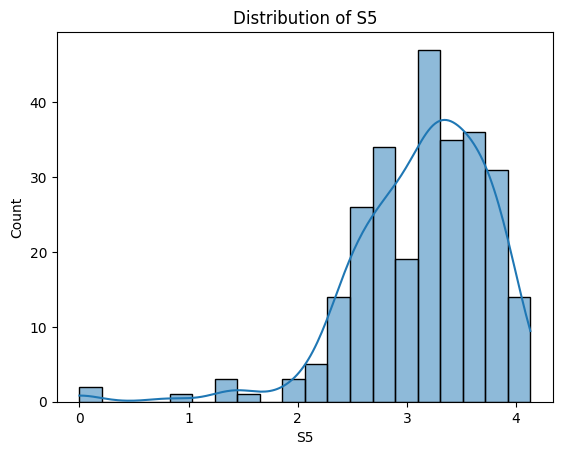

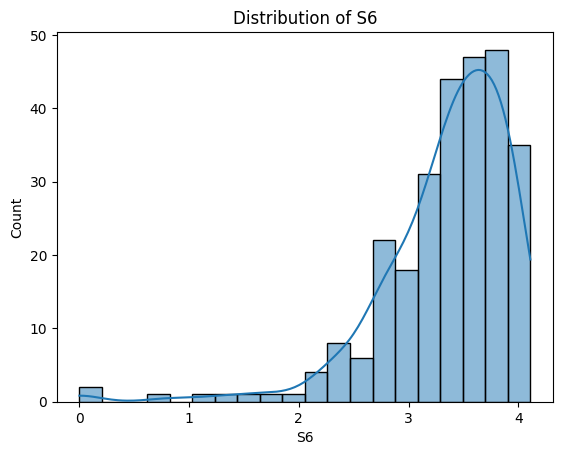

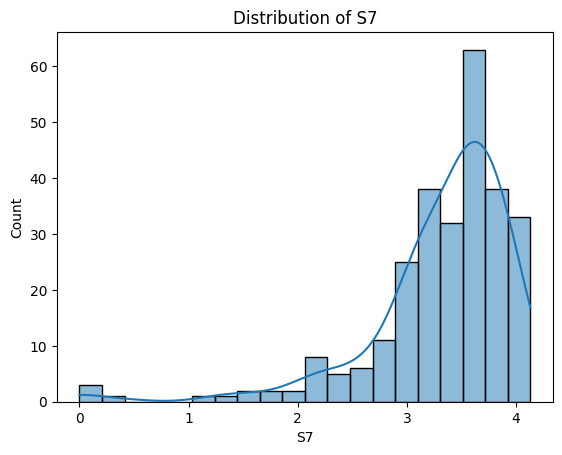

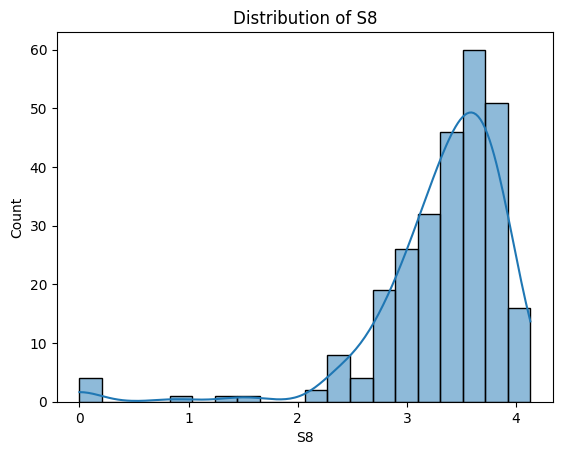

In [ ]:
num_pre_cols = ["FinalGPA", "Zscore", "EnglishMarks","S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]

for col in num_pre_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

In [14]:
for col in num_pre_cols:
    print(col, df[col].skew())

FinalGPA -0.8071225975321203
Zscore 1.2325351184579059
EnglishMarks -0.31189208416499853
S1 -0.16354167254123955
S2 -0.6950050739283188
S3 -0.3819073977188497
S4 -1.1590855519282668
S5 -1.4822995511693433
S6 -2.1087836140404606
S7 -2.2817083052764624
S8 -2.8163100739317257


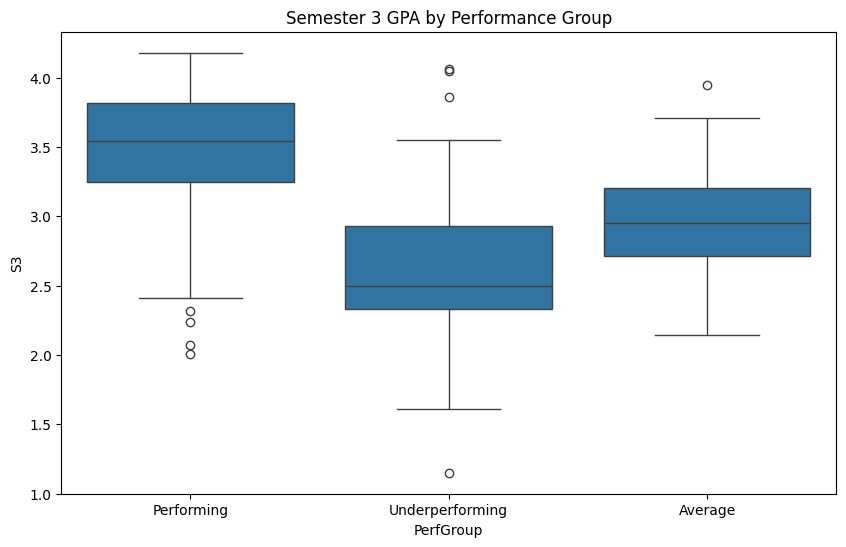

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="PerfGroup",
    y="S3"
)
plt.title("Semester 3 GPA by Performance Group")
plt.show()

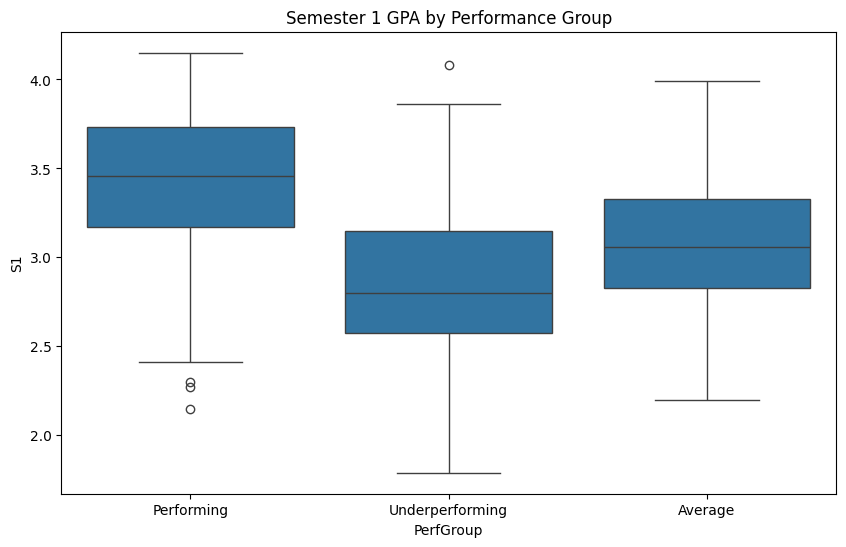

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="PerfGroup",
    y="S1"
)
plt.title("Semester 1 GPA by Performance Group")
plt.show()

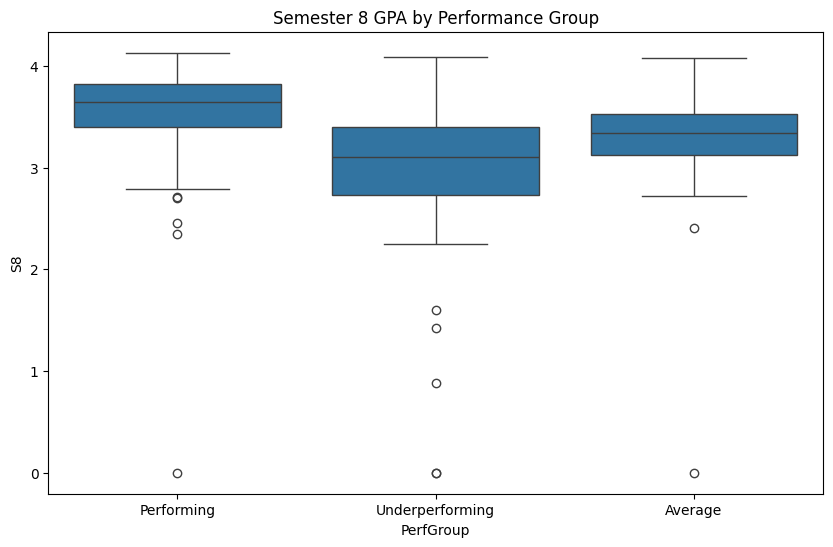

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="PerfGroup",
    y="S8"
)
plt.title("Semester 8 GPA by Performance Group")
plt.show()

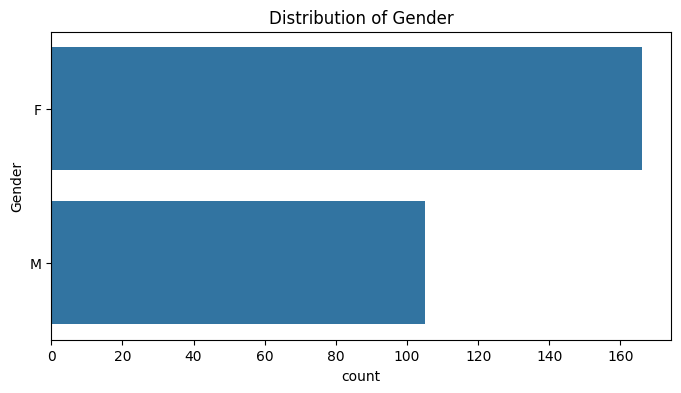

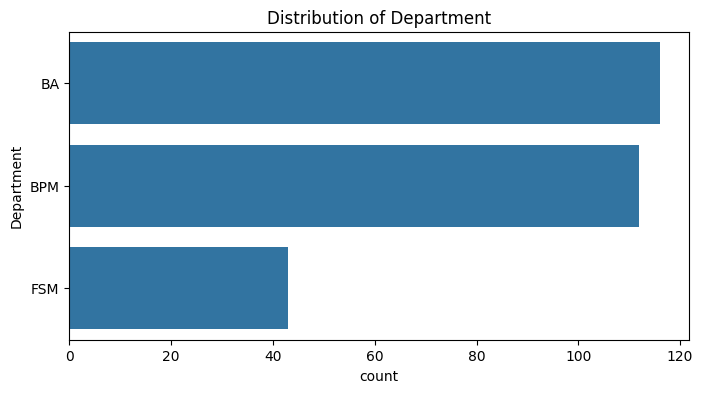

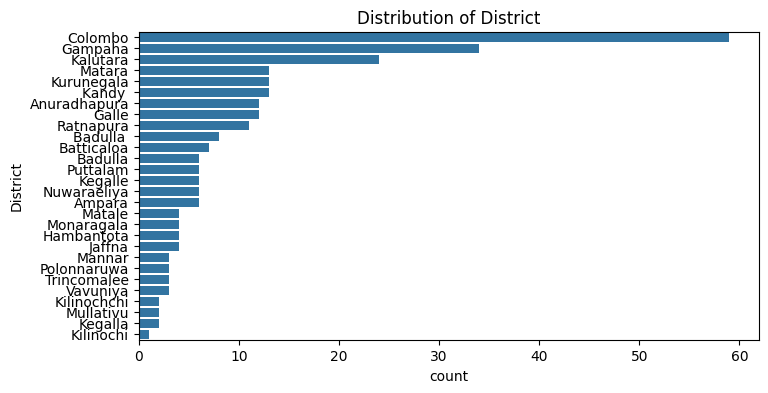

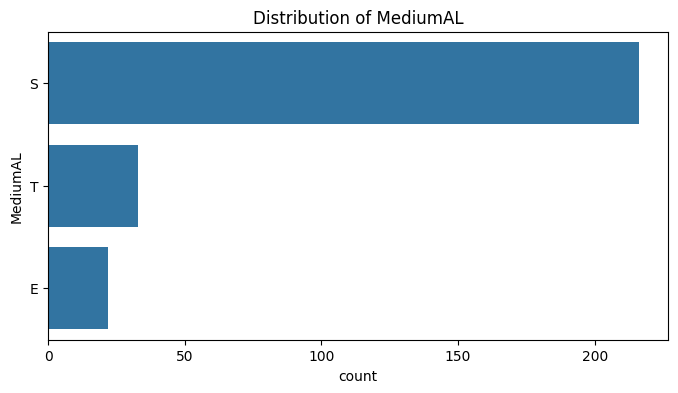

In [17]:
cat_cols = ["Gender", "Department", "District", "MediumAL"]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

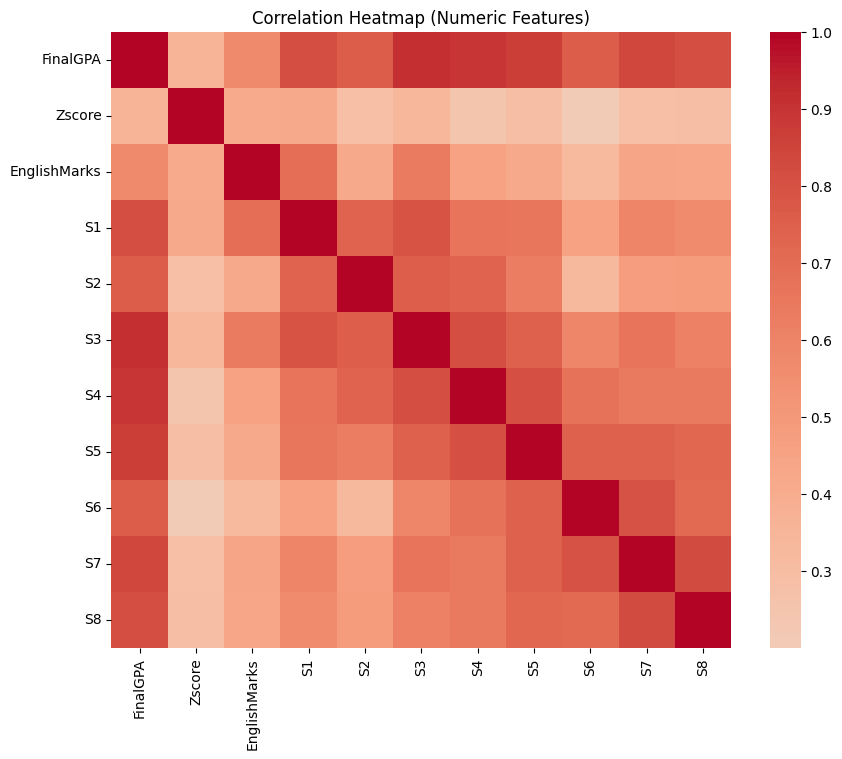

In [18]:
num_cols_for_corr = ["FinalGPA", "Zscore", "EnglishMarks", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]

plt.figure(figsize=(10,8))
sns.heatmap(
    df[num_cols_for_corr].corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()